EXPERIMENT 4
EXPLORATION VS. EXPLOITATION ANALYSIS USING MULTI-ARMED BANDITS

10 SAMPLE DATASET RECORDS


,Arm_1_Probability,Arm_2_Probability,Arm_3_Probability,Arm_4_Probability
0,0.527,0.450,0.114,0.697
1,0.934,0.546,0.611,0.756
2,0.611,0.480,0.941,0.734
3,0.875,0.692,0.766,0.451
4,0.639,0.787,0.592,0.691
5,0.686,0.328,0.738,0.747
6,0.788,0.063,0.499,0.759
7,0.913,0.797,0.377,0.763
8,0.757,0.338,0.769,0.536
9,0.641,0.553,0.567,0.891


Total Records: 500

DATASET SUMMARY


,min,max,mean,std
Arm_1_Probability,0.05,0.95,0.480,0.232
Arm_2_Probability,0.05,0.95,0.508,0.222
Arm_3_Probability,0.05,0.95,0.483,0.220
Arm_4_Probability,0.05,0.95,0.515,0.224



DOWNLOAD COMPLETE DATASET:


...

<IPython.core.display.Javascript object>


ALGORITHM COMPARISON


,Algorithm,Total Reward,Average Reward,Final Regret,Most Selected Arm
0,Epsilon-Greedy,404,0.808,20.80,4
1,UCB,387,0.774,45.05,4
2,Thompson Sampling,406,0.812,6.50,4



SUMMARY RESULTS


,Metric,Result
0,Dataset Records,500
1,Number of Arms,4
2,Number of Rounds,500
3,Best Arm,4
4,Best Arm Probability,0.85
5,Best Performing Algorithm,Thompson Sampling


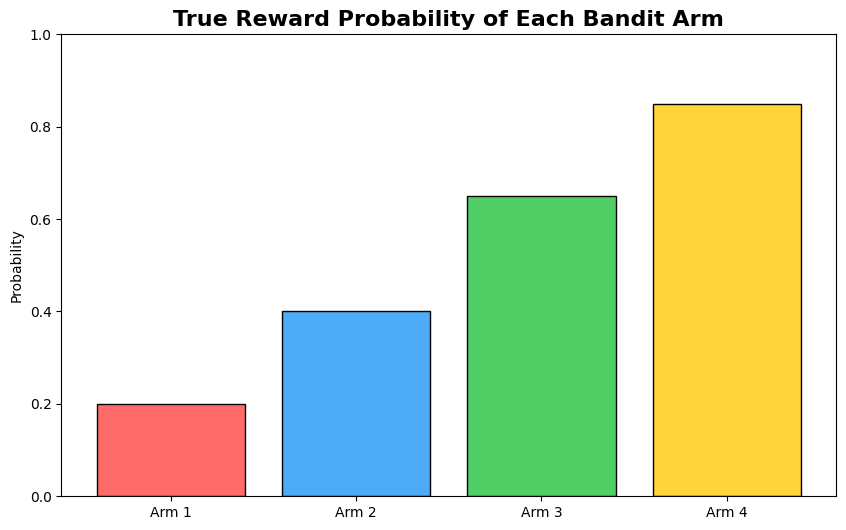

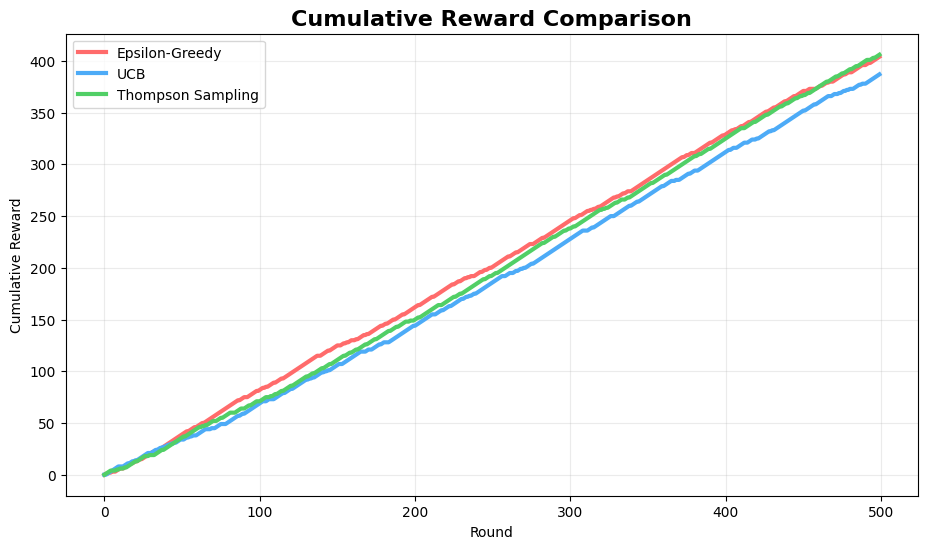

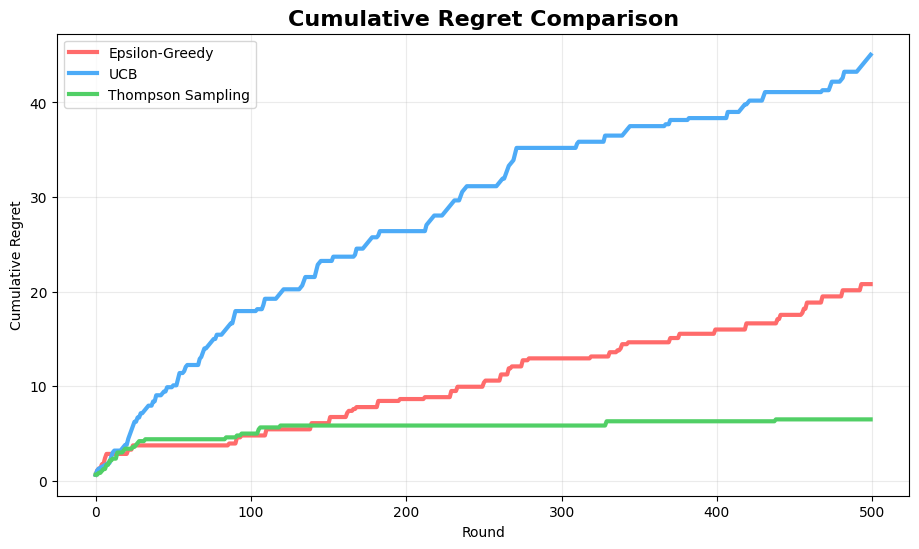

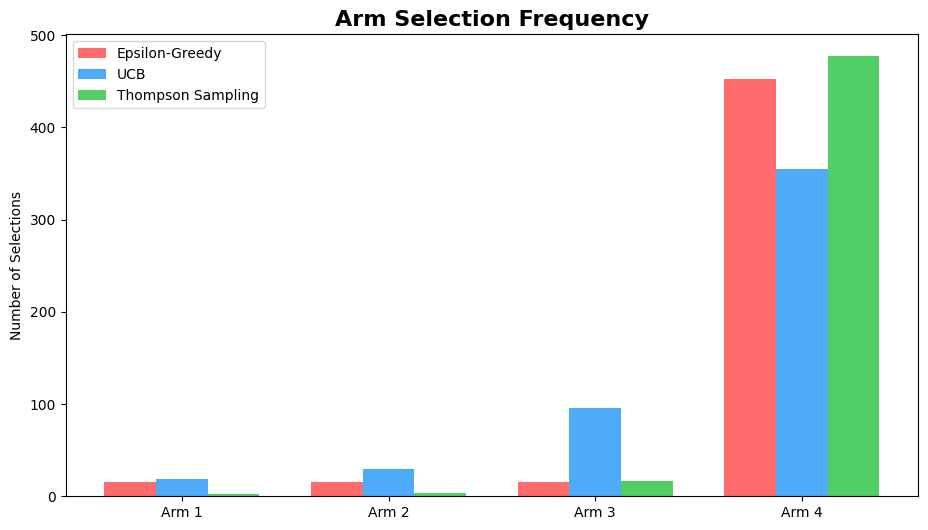

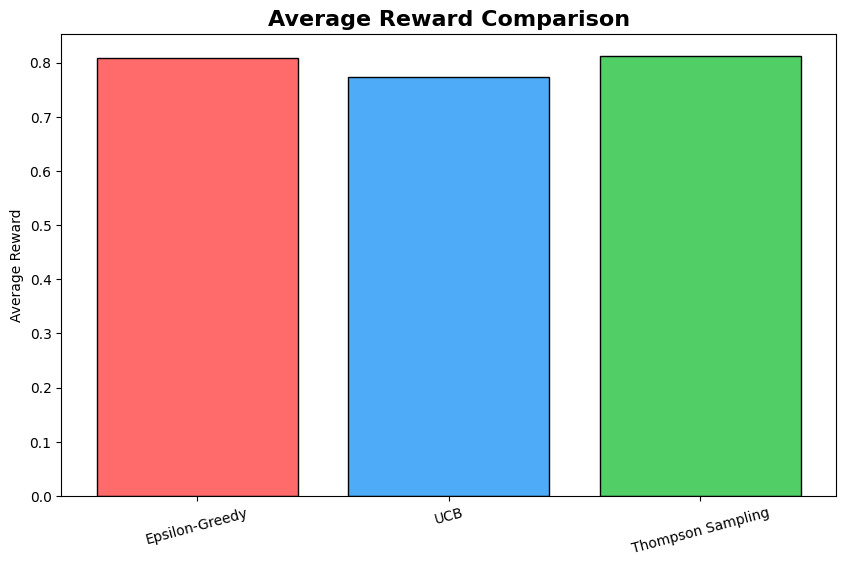


FINAL RESULT
Best performing algorithm: Thompson Sampling

Experiment 4 completed successfully.


In [ ]:
# ==============================================================
# EXPERIMENT 4
# EXPLORATION VS. EXPLOITATION ANALYSIS
# USING MULTI-ARMED BANDIT ALGORITHMS
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from IPython.display import display, FileLink
from google.colab import files

np.random.seed(42)

print("=" * 80)
print("EXPERIMENT 4")
print("EXPLORATION VS. EXPLOITATION ANALYSIS USING MULTI-ARMED BANDITS")
print("=" * 80)

# ==============================================================
# 1. GMM DATASET
# ==============================================================

N = 500

base_data = np.random.uniform(
    0.1,
    0.9,
    size=(N, 4)
)

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(base_data)

generated = gmm.sample(N)[0]

dataset = pd.DataFrame(
    generated,
    columns=[
        "Arm_1_Probability",
        "Arm_2_Probability",
        "Arm_3_Probability",
        "Arm_4_Probability"
    ]
)

dataset = dataset.clip(0.05, 0.95).round(3)

# ==============================================================
# 2. DISPLAY 10 SAMPLES
# ==============================================================

print("\n10 SAMPLE DATASET RECORDS")

display(dataset.head(10))

print("Total Records:", len(dataset))

# ==============================================================
# 3. DATASET SUMMARY
# ==============================================================

summary_dataset = dataset.describe().T[
    ["min", "max", "mean", "std"]
].round(3)

print("\nDATASET SUMMARY")

display(summary_dataset)

# ==============================================================
# 4. DOWNLOAD
# ==============================================================

filename = "Experiment_4_Bandit_GMM_Dataset.csv"

dataset.to_csv(
    filename,
    index=False
)

print("\nDOWNLOAD COMPLETE DATASET:")

display(FileLink(filename))

files.download(filename)

# ==============================================================
# 5. BANDIT PARAMETERS
# ==============================================================

TRUE_PROBABILITIES = np.array([
    0.20,
    0.40,
    0.65,
    0.85
])

ARMS = 4
ROUNDS = 500

# ==============================================================
# 6. EPSILON GREEDY
# ==============================================================

def epsilon_greedy(epsilon=0.10):

    counts = np.zeros(ARMS)
    rewards = np.zeros(ARMS)

    reward_history = []
    selected_arms = []

    for t in range(ROUNDS):

        if t < ARMS:
            arm = t

        elif np.random.rand() < epsilon:
            arm = np.random.randint(ARMS)

        else:

            means = np.divide(
                rewards,
                counts,
                out=np.zeros(ARMS),
                where=counts != 0
            )

            arm = np.argmax(means)

        reward = int(
            np.random.rand()
            < TRUE_PROBABILITIES[arm]
        )

        counts[arm] += 1
        rewards[arm] += reward

        reward_history.append(reward)
        selected_arms.append(arm)

    return (
        np.array(reward_history),
        np.array(selected_arms),
        counts
    )

# ==============================================================
# 7. UCB
# ==============================================================

def ucb():

    counts = np.zeros(ARMS)
    rewards = np.zeros(ARMS)

    reward_history = []
    selected_arms = []

    for t in range(ROUNDS):

        if t < ARMS:

            arm = t

        else:

            means = rewards / counts

            confidence = np.sqrt(
                2 * np.log(t + 1)
                / counts
            )

            arm = np.argmax(
                means + confidence
            )

        reward = int(
            np.random.rand()
            < TRUE_PROBABILITIES[arm]
        )

        counts[arm] += 1
        rewards[arm] += reward

        reward_history.append(reward)
        selected_arms.append(arm)

    return (
        np.array(reward_history),
        np.array(selected_arms),
        counts
    )

# ==============================================================
# 8. THOMPSON SAMPLING
# ==============================================================

def thompson_sampling():

    alpha = np.ones(ARMS)
    beta = np.ones(ARMS)

    reward_history = []
    selected_arms = []

    for _ in range(ROUNDS):

        samples = np.random.beta(
            alpha,
            beta
        )

        arm = np.argmax(samples)

        reward = int(
            np.random.rand()
            < TRUE_PROBABILITIES[arm]
        )

        if reward == 1:
            alpha[arm] += 1
        else:
            beta[arm] += 1

        reward_history.append(reward)
        selected_arms.append(arm)

    counts = np.bincount(
        selected_arms,
        minlength=ARMS
    )

    return (
        np.array(reward_history),
        np.array(selected_arms),
        counts
    )

# ==============================================================
# 9. RUN ALGORITHMS
# ==============================================================

eps_rewards, eps_arms, eps_counts = epsilon_greedy()
ucb_rewards, ucb_arms, ucb_counts = ucb()
ts_rewards, ts_arms, ts_counts = thompson_sampling()

# ==============================================================
# 10. CUMULATIVE REWARD
# ==============================================================

eps_cumulative = np.cumsum(eps_rewards)
ucb_cumulative = np.cumsum(ucb_rewards)
ts_cumulative = np.cumsum(ts_rewards)

# ==============================================================
# 11. REGRET
# ==============================================================

optimal_probability = max(TRUE_PROBABILITIES)

eps_regret = np.cumsum(
    optimal_probability - TRUE_PROBABILITIES[eps_arms]
)

ucb_regret = np.cumsum(
    optimal_probability - TRUE_PROBABILITIES[ucb_arms]
)

ts_regret = np.cumsum(
    optimal_probability - TRUE_PROBABILITIES[ts_arms]
)

# ==============================================================
# 12. COMPARISON TABLE
# ==============================================================

comparison = pd.DataFrame({
    "Algorithm": [
        "Epsilon-Greedy",
        "UCB",
        "Thompson Sampling"
    ],

    "Total Reward": [
        eps_rewards.sum(),
        ucb_rewards.sum(),
        ts_rewards.sum()
    ],

    "Average Reward": [
        eps_rewards.mean(),
        ucb_rewards.mean(),
        ts_rewards.mean()
    ],

    "Final Regret": [
        eps_regret[-1],
        ucb_regret[-1],
        ts_regret[-1]
    ],

    "Most Selected Arm": [
        np.argmax(eps_counts) + 1,
        np.argmax(ucb_counts) + 1,
        np.argmax(ts_counts) + 1
    ]
}).round(3)

print("\n" + "=" * 80)
print("ALGORITHM COMPARISON")
print("=" * 80)

display(comparison)

# ==============================================================
# 13. SUMMARY TABLE
# ==============================================================

best_algorithm = comparison.loc[
    comparison["Average Reward"].idxmax(),
    "Algorithm"
]

summary = pd.DataFrame({
    "Metric": [
        "Dataset Records",
        "Number of Arms",
        "Number of Rounds",
        "Best Arm",
        "Best Arm Probability",
        "Best Performing Algorithm"
    ],

    "Result": [
        len(dataset),
        ARMS,
        ROUNDS,
        np.argmax(TRUE_PROBABILITIES) + 1,
        max(TRUE_PROBABILITIES),
        best_algorithm
    ]
})

print("\nSUMMARY RESULTS")

display(summary)

# ==============================================================
# 14. VISUALIZATION 1
# ARM PROBABILITIES
# ==============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    ["Arm 1", "Arm 2", "Arm 3", "Arm 4"],
    TRUE_PROBABILITIES,
    color=[
        "#ff6b6b",
        "#4dabf7",
        "#51cf66",
        "#ffd43b"
    ],
    edgecolor="black"
)

plt.title(
    "True Reward Probability of Each Bandit Arm",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Probability")
plt.ylim(0, 1)

plt.show()

# ==============================================================
# 15. VISUALIZATION 2
# CUMULATIVE REWARD
# ==============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    eps_cumulative,
    label="Epsilon-Greedy",
    color="#ff6b6b",
    linewidth=3
)

plt.plot(
    ucb_cumulative,
    label="UCB",
    color="#4dabf7",
    linewidth=3
)

plt.plot(
    ts_cumulative,
    label="Thompson Sampling",
    color="#51cf66",
    linewidth=3
)

plt.title(
    "Cumulative Reward Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Round")
plt.ylabel("Cumulative Reward")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 16. VISUALIZATION 3
# CUMULATIVE REGRET
# ==============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    eps_regret,
    label="Epsilon-Greedy",
    color="#ff6b6b",
    linewidth=3
)

plt.plot(
    ucb_regret,
    label="UCB",
    color="#4dabf7",
    linewidth=3
)

plt.plot(
    ts_regret,
    label="Thompson Sampling",
    color="#51cf66",
    linewidth=3
)

plt.title(
    "Cumulative Regret Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Round")
plt.ylabel("Cumulative Regret")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 17. VISUALIZATION 4
# ARM SELECTION FREQUENCY
# ==============================================================

x = np.arange(ARMS)
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    eps_counts,
    width,
    label="Epsilon-Greedy",
    color="#ff6b6b"
)

plt.bar(
    x,
    ucb_counts,
    width,
    label="UCB",
    color="#4dabf7"
)

plt.bar(
    x + width,
    ts_counts,
    width,
    label="Thompson Sampling",
    color="#51cf66"
)

plt.xticks(
    x,
    ["Arm 1", "Arm 2", "Arm 3", "Arm 4"]
)

plt.title(
    "Arm Selection Frequency",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Selections")
plt.legend()

plt.show()

# ==============================================================
# 18. VISUALIZATION 5
# AVERAGE REWARD
# ==============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Algorithm"],
    comparison["Average Reward"],
    color=[
        "#ff6b6b",
        "#4dabf7",
        "#51cf66"
    ],
    edgecolor="black"
)

plt.title(
    "Average Reward Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Average Reward")
plt.xticks(rotation=15)

plt.show()

print("\n" + "=" * 80)
print("FINAL RESULT")
print("=" * 80)

print(
    f"Best performing algorithm: {best_algorithm}"
)

print(
    "\nExperiment 4 completed successfully."
)